In [151]:
from sentiment_data import read_sentiment_examples, read_blind_sst_examples
from utils import Indexer
from models_copy import UnigramFeatureExtractor, LogisticRegressionClassifier
import numpy as np
from models_copy import SentimentClassifier

In [152]:
sentences = read_sentiment_examples("data/train.txt")
print(type(sentences[0].words), type(sentences[0].label))

words = sentences[0].words
print(words)

_ix = Indexer()
extractor = UnigramFeatureExtractor(_ix)

<class 'list'> <class 'int'>
['the', 'rock', 'is', 'destined', 'to', 'be', 'the', '21st', 'century', "'s", 'new', '``', 'conan', "''", 'and', 'that', 'he', "'s", 'going', 'to', 'make', 'a', 'splash', 'even', 'greater', 'than', 'arnold', 'schwarzenegger', ',', 'jean-claud', 'van', 'damme', 'or', 'steven', 'segal', '.']


In [153]:
from sentiment_data import read_word_embeddings, WordEmbeddings

In [154]:
train_exs = read_sentiment_examples("data/train.txt")
dev_exs = read_sentiment_examples("data/dev.txt")
test_exs = read_blind_sst_examples("data/test-blind.txt")
print(repr(len(train_exs)) + " / " + repr(len(dev_exs)) + " / " + repr(len(test_exs)) + " train/dev/test examples")

word_embeddings = read_word_embeddings("data/glove.6B.50d-relativized.txt")

6920 / 872 / 1821 train/dev/test examples
Read in 14923 vectors of size 50


In [ ]:
['of', 'to', 'and', 'a', "'s", 'the', 'she']

In [155]:
import torch
import torch.nn as nn

In [156]:
class DAN(nn.Module):
    def __init__(self, word_embeddings, hidden_layer, num_classes=1):
        super(DAN, self).__init__()
        self.embeddings = word_embeddings.get_initialized_embedding_layer()
        self.embed_dim = self.embeddings.embedding_dim
        self.hidden = hidden_layer
        self.classes = num_classes

        self.linear = nn.Linear(self.embed_dim, self.hidden, bias=True)
        self.output = nn.Linear(self.hidden, self.classes, bias=True)

    def forward(self, word_indices):
        if type(word_indices) == list: word_indices = torch.tensor(word_indices, dtype=torch.long)
        embeds = self.embeddings(word_indices)
        embeds_avg = embeds.mean(axis=0)
        x = nn.functional.relu(self.linear(embeds_avg))
        x = torch.sigmoid(self.output(x))
        return x

In [157]:
class NeuralSentimentClassifier(SentimentClassifier):
    """
    Implement your NeuralSentimentClassifier here. This should wrap an instance of the network with learned weights
    along with everything needed to run it on new data (word embeddings, etc.)
    """
    def __init__(self, network, word_embeddings):
        self.embeddings = word_embeddings
        self.network = network

    def predict(self, sentence):
        word_indices = [self.embeddings.word_indexer.objs_to_ints[word] for word in sentence]
        prob = self.network(word_indices)
        print(prob)
        return 1 if prob > 0.5 else 0

In [ ]:
model = DAN(word_embeddings, 10)
out = model(temp_idxs)
out

tensor([0.5698], grad_fn=<SigmoidBackward0>)

In [145]:
clf = NeuralSentimentClassifier(model, word_embeddings)

In [150]:
out.item()

0.5698268413543701

In [147]:
clf.predict(temp_words)

tensor([0.4313], grad_fn=<SigmoidBackward0>)


0

In [162]:
import pickle

results_1 = pickle.load(open('results/decay_lr_1.pkl', 'rb'))
results_2 = pickle.load(open('results/decay_lr_2.pkl', 'rb'))
results_3 = pickle.load(open('results/constant_lr.pkl', 'rb'))
print(results_1['lr_schedule'], results_2['lr_schedule'], results_3['lr_schedule'])

lr = decay with a factor or 0.05 lr = decay with a factor or 1 lr = constant 0.005


In [176]:
experiments = {
    'constant': {
        "log_likelihoods": results_3['log_likelihoods'],
        "dev_accuracies": results_3['dev_accuracies']
    },
    'decay(k=0.05)': {
        "log_likelihoods": results_1['log_likelihoods'],
        "dev_accuracies": results_1['dev_accuracies']
    },
    'decay(k=1)': {
        "log_likelihoods": results_2['log_likelihoods'],
        "dev_accuracies": results_2['dev_accuracies']
    }
}

In [177]:
for lr, data in experiments.items():
    print(lr, data)

constant {'log_likelihoods': [np.float64(-4293.193218755796), np.float64(-4051.5203135733145), np.float64(-3864.8918757893616), np.float64(-3716.292228594912), np.float64(-3606.889840204199), np.float64(-3499.020072967738), np.float64(-3397.4181292168228), np.float64(-3310.8694381747855), np.float64(-3232.860606699736), np.float64(-3160.0026839439565), np.float64(-3104.169677155574), np.float64(-3038.563474259148), np.float64(-2978.4038888946275), np.float64(-2929.61269247946), np.float64(-2882.8182134436374), np.float64(-2830.3715342146243), np.float64(-2785.007316877104), np.float64(-2748.4714906181084), np.float64(-2727.4088774557813), np.float64(-2662.8804520166423), np.float64(-2629.10028054452), np.float64(-2592.857180649947), np.float64(-2559.873699133112), np.float64(-2527.518938638506), np.float64(-2498.928298515615), np.float64(-2466.4867048738106), np.float64(-2436.3470137752784), np.float64(-2411.558897657901), np.float64(-2384.948230155993), np.float64(-2361.505820056196)]

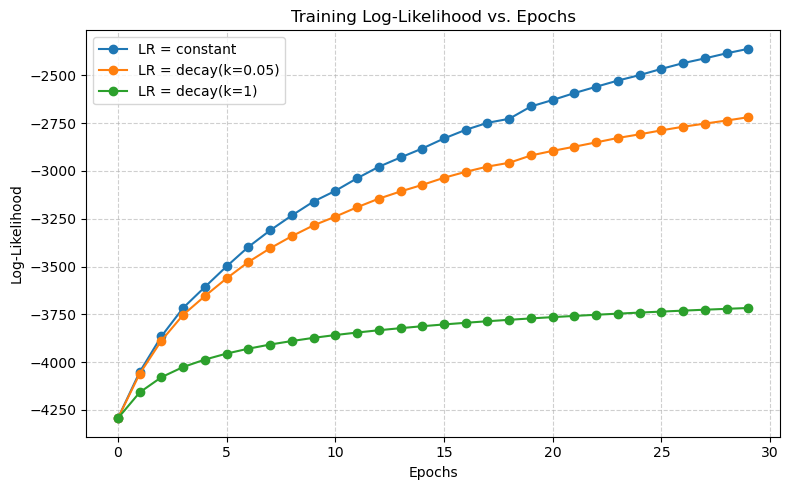

In [178]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
for lr, data in experiments.items():
    plt.plot(data["log_likelihoods"], marker='o', label=f'LR = {lr}')

plt.title('Training Log-Likelihood vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Log-Likelihood')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig('training_log_likelihood.png')
plt.show()

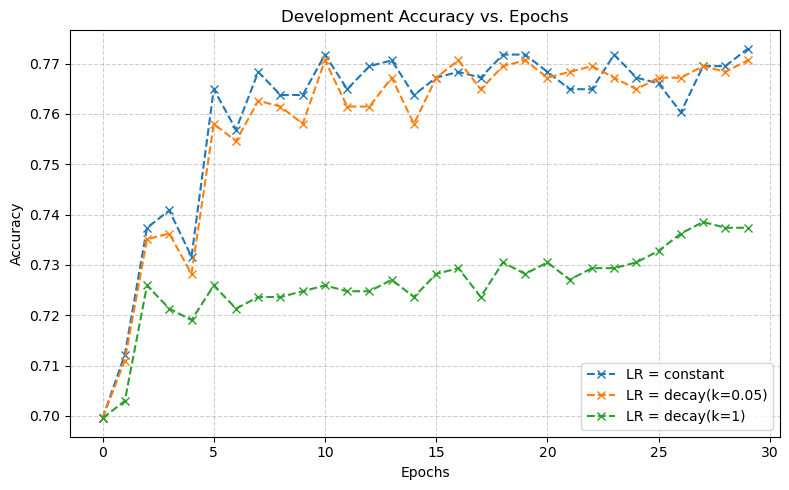

In [179]:

plt.figure(figsize=(8, 5))
for lr, data in experiments.items():
    plt.plot(data["dev_accuracies"], marker='x', linestyle='--', label=f'LR = {lr}')

plt.title('Development Accuracy vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig('development_accuracy.png')
plt.show()
